<a href="https://colab.research.google.com/github/partha-pkp/data-mining-drug-discovery/blob/main/avanie/Rotation_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 0) LOAD DATA
# =========================================================

!pip -q install liac-arff

import pandas as pd
from scipy.io import arff

try:
    from google.colab import files
    uploaded = files.upload()
    ARFF_FILE = list(uploaded.keys())[0]
except:
    ARFF_FILE = "your_file.arff"  # change if needed

data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Shape:", df.shape)
print("Positive rate:", y.mean())

Saving input_data_no_smiles.arff to input_data_no_smiles (2).arff
Shape: (4866, 201)
Positive rate: 0.02116728318947801


In [ ]:
# =========================================================
# 1) INSTALLS + IMPORTS + HELPERS
# =========================================================

!pip -q install aeon scikit-learn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)

from aeon.classification.sklearn import RotationForestClassifier

# =========================================================
# FULL METRICS (CLASS 0, CLASS 1, OVERALL)
# =========================================================

from sklearn.metrics import classification_report

def print_full_metrics(y_true, y_pred, title="Model"):
    print("\n" + "="*70)
    print(f"FULL METRICS: {title}")
    print("="*70)

    print(classification_report(
        y_true,
        y_pred,
        target_names=["Non-Senolytic (0)", "Senolytic (1)"],
        digits=4
    ))


# -------------------------------
# Threshold selection
# -------------------------------
def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return thresholds[best_idx]


# -------------------------------
# Evaluation
# -------------------------------
def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }


# -------------------------------
# Rotation Forest builder
# -------------------------------
def make_rotation_forest(class_weight, n_estimators, min_group, max_group, remove_proportion, max_depth=None):

    base_tree = DecisionTreeClassifier(
        criterion="entropy",
        class_weight=class_weight,
        max_depth=max_depth,
        random_state=42
    )

    return RotationForestClassifier(
        n_estimators=n_estimators,
        min_group=min_group,
        max_group=max_group,
        remove_proportion=remove_proportion,
        base_estimator=base_tree,
        random_state=42,
        n_jobs=-1
    )

In [ ]:
# =========================================================
# 2) PARAM GRID
# =========================================================

TARGET_RECALL = 0.80

ROTATION_PARAM_GRID = [
    {
        "name": "rotf_balanced_50",
        "class_weight": "balanced",
        "n_estimators": 50,
        "max_depth": None,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_balanced_100",
        "class_weight": "balanced",
        "n_estimators": 100,
        "max_depth": None,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_balanced_100_depth10",
        "class_weight": "balanced",
        "n_estimators": 100,
        "max_depth": 10,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_pos5_50",
        "class_weight": {0: 1, 1: 5},
        "n_estimators": 50,
        "max_depth": None,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_pos10_50",
        "class_weight": {0: 1, 1: 10},
        "n_estimators": 50,
        "max_depth": None,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    }
]

In [ ]:
# =========================================================
# 3) TRAIN ROTATION FOREST (NO THRESHOLD TUNING)
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rotation_results = []

for cfg in ROTATION_PARAM_GRID:
    print("\n" + "=" * 80)
    print("Running:", cfg["name"])
    print("=" * 80)

    y_true_all = []
    y_prob_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        # -------------------------------
        # Split
        # -------------------------------
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        # -------------------------------
        # Fold-safe imputation
        # -------------------------------
        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        # -------------------------------
        # Build model
        # -------------------------------
        clf = make_rotation_forest(
            class_weight=cfg.get("class_weight", "balanced"),
            n_estimators=cfg.get("n_estimators", 50),
            min_group=cfg.get("min_group", 3),
            max_group=cfg.get("max_group", 3),
            remove_proportion=cfg.get("remove_proportion", 0.5),
            max_depth=cfg.get("max_depth", None)
        )

        clf.fit(X_train, y_train)
        prob = clf.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test.tolist())
        y_prob_all.extend(prob.tolist())

        print(f"Fold {fold_idx}/5 done")

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    # 🔥 FIXED THRESHOLD
    chosen_threshold = 0.5

    metrics = evaluate_at_threshold(
        y_true=y_true_all,
        y_prob=y_prob_all,
        threshold=chosen_threshold
    )

    rotation_results.append({
        "name": cfg["name"],
        "config": cfg,
        "y_true": y_true_all,
        "y_prob": y_prob_all,
        "metrics": metrics
    })

    # -------------------------------
    # Print results
    # -------------------------------
    print("\n--- Default Threshold (0.5) Results ---")
    print(f"Precision (class 1): {metrics['precision']:.4f}")
    print(f"Recall    (class 1): {metrics['recall']:.4f}")
    print(f"F1        (class 1): {metrics['f1']:.4f}")
    print(f"Accuracy  (overall): {metrics['accuracy']:.4f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.4f}")
    print(f"Avg Precision     : {metrics['avg_precision']:.4f}")

    print("\nConfusion Matrix:")
    print(metrics["cm"])

    print("\nFull Classification Report:")
    print(classification_report(
        y_true_all,
        metrics["y_pred"],
        target_names=["Non-Senolytic (0)", "Senolytic (1)"],
        digits=4,
        zero_division=0
    ))


Running: rotf_balanced_50
Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

--- Default Threshold (0.5) Results ---
Precision (class 1): 0.3400
Recall    (class 1): 0.1650
F1        (class 1): 0.2222
Accuracy  (overall): 0.9755
ROC-AUC           : 0.7202
Avg Precision     : 0.1445

Confusion Matrix:
[[4730   33]
 [  86   17]]

Full Classification Report:
                   precision    recall  f1-score   support

Non-Senolytic (0)     0.9821    0.9931    0.9876      4763
    Senolytic (1)     0.3400    0.1650    0.2222       103

         accuracy                         0.9755      4866
        macro avg     0.6611    0.5791    0.6049      4866
     weighted avg     0.9686    0.9755    0.9714      4866


Running: rotf_balanced_100
Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

--- Default Threshold (0.5) Results ---
Precision (class 1): 0.3542
Recall    (class 1): 0.1650
F1        (class 1): 0.2252
Accuracy  (overall): 0.9760
ROC-AUC      

In [ ]:
# =========================================================
# 6) FOLLOW-UP HELPERS + SMARTER HIGH-RECALL GRID
# =========================================================

def threshold_for_target_recall_safe(y_true, y_prob, target_recall=0.80, min_threshold=0.05):
    """
    Follow-up threshold function only.
    Keeps recall >= target_recall, but prevents collapse to near-zero thresholds.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where((recalls_t >= target_recall) & (thresholds >= min_threshold))[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return thresholds[best_idx]


FOLLOWUP_ROTATION_GRID = [
    {
        "name": "rotf_balanced_150_depth10",
        "class_weight": "balanced",
        "n_estimators": 150,
        "max_depth": 10,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_balanced_200_depth10",
        "class_weight": "balanced",
        "n_estimators": 200,
        "max_depth": 10,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_pos5_100_depth10",
        "class_weight": {0: 1, 1: 5},
        "n_estimators": 100,
        "max_depth": 10,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    },
    {
        "name": "rotf_balanced_100_depth8",
        "class_weight": "balanced",
        "n_estimators": 100,
        "max_depth": 8,
        "min_group": 3,
        "max_group": 3,
        "remove_proportion": 0.5
    }
]

print("Follow-up Rotation Forest configs:")
for cfg in FOLLOWUP_ROTATION_GRID:
    print(cfg)

Follow-up Rotation Forest configs:
{'name': 'rotf_balanced_150_depth10', 'class_weight': 'balanced', 'n_estimators': 150, 'max_depth': 10, 'min_group': 3, 'max_group': 3, 'remove_proportion': 0.5}
{'name': 'rotf_balanced_200_depth10', 'class_weight': 'balanced', 'n_estimators': 200, 'max_depth': 10, 'min_group': 3, 'max_group': 3, 'remove_proportion': 0.5}
{'name': 'rotf_pos5_100_depth10', 'class_weight': {0: 1, 1: 5}, 'n_estimators': 100, 'max_depth': 10, 'min_group': 3, 'max_group': 3, 'remove_proportion': 0.5}
{'name': 'rotf_balanced_100_depth8', 'class_weight': 'balanced', 'n_estimators': 100, 'max_depth': 8, 'min_group': 3, 'max_group': 3, 'remove_proportion': 0.5}


In [ ]:
# =========================================================
# 7) FOLLOW-UP ROTATION FOREST RUNS
#    (default threshold + safe-tuned threshold)
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

skf_followup = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rotation_followup_results = []

for cfg in FOLLOWUP_ROTATION_GRID:
    print("\n" + "=" * 80)
    print("Running follow-up model:", cfg["name"])
    print("=" * 80)

    y_true_all = []
    y_prob_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf_followup.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        # fold-safe imputation
        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        clf = make_rotation_forest(
            class_weight=cfg["class_weight"],
            n_estimators=cfg["n_estimators"],
            min_group=cfg["min_group"],
            max_group=cfg["max_group"],
            remove_proportion=cfg["remove_proportion"],
            max_depth=cfg["max_depth"]
        )

        clf.fit(X_train, y_train)
        prob = clf.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test.tolist())
        y_prob_all.extend(prob.tolist())

        print(f"Fold {fold_idx}/5 done")

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    # -------------------------------
    # Default threshold
    # -------------------------------
    default_metrics = evaluate_at_threshold(
        y_true=y_true_all,
        y_prob=y_prob_all,
        threshold=0.5
    )

    # -------------------------------
    # Safe-tuned threshold
    # -------------------------------
    tuned_threshold = threshold_for_target_recall_safe(
        y_true=y_true_all,
        y_prob=y_prob_all,
        target_recall=TARGET_RECALL,
        min_threshold=0.05
    )

    if tuned_threshold is None:
        tuned_threshold = 0.5
        print("\nNo safe threshold reached recall target; keeping threshold = 0.5")

    tuned_metrics = evaluate_at_threshold(
        y_true=y_true_all,
        y_prob=y_prob_all,
        threshold=tuned_threshold
    )

    rotation_followup_results.append({
        "name": cfg["name"],
        "config": cfg,
        "y_true": y_true_all,
        "y_prob": y_prob_all,
        "default_metrics": default_metrics,
        "tuned_threshold": tuned_threshold,
        "tuned_metrics": tuned_metrics
    })

    # -------------------------------
    # Print default
    # -------------------------------
    print("\n--- DEFAULT THRESHOLD (0.5) ---")
    print(f"Precision (class 1): {default_metrics['precision']:.4f}")
    print(f"Recall    (class 1): {default_metrics['recall']:.4f}")
    print(f"F1        (class 1): {default_metrics['f1']:.4f}")
    print(f"Accuracy  (overall): {default_metrics['accuracy']:.4f}")
    print(f"ROC-AUC           : {default_metrics['roc_auc']:.4f}")
    print(f"Avg Precision     : {default_metrics['avg_precision']:.4f}")
    print(default_metrics["cm"])

    # -------------------------------
    # Print safe-tuned
    # -------------------------------
    print("\n--- SAFE-TUNED THRESHOLD ---")
    print(f"Threshold         : {tuned_threshold:.6f}")
    print(f"Precision (class 1): {tuned_metrics['precision']:.4f}")
    print(f"Recall    (class 1): {tuned_metrics['recall']:.4f}")
    print(f"F1        (class 1): {tuned_metrics['f1']:.4f}")
    print(f"Accuracy  (overall): {tuned_metrics['accuracy']:.4f}")
    print(f"ROC-AUC           : {tuned_metrics['roc_auc']:.4f}")
    print(f"Avg Precision     : {tuned_metrics['avg_precision']:.4f}")
    print(tuned_metrics["cm"])

    print("\nFull Classification Report (SAFE-TUNED):")
    print(classification_report(
        y_true_all,
        tuned_metrics["y_pred"],
        target_names=["Non-Senolytic (0)", "Senolytic (1)"],
        digits=4,
        zero_division=0
    ))


Running follow-up model: rotf_balanced_150_depth10
Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

--- DEFAULT THRESHOLD (0.5) ---
Precision (class 1): 0.2577
Recall    (class 1): 0.2427
F1        (class 1): 0.2500
Accuracy  (overall): 0.9692
ROC-AUC           : 0.8170
Avg Precision     : 0.1758
[[4691   72]
 [  78   25]]

--- SAFE-TUNED THRESHOLD ---
Threshold         : 0.054461
Precision (class 1): 0.0453
Recall    (class 1): 0.8058
F1        (class 1): 0.0858
Accuracy  (overall): 0.6367
ROC-AUC           : 0.8170
Avg Precision     : 0.1758
[[3015 1748]
 [  20   83]]

Full Classification Report (SAFE-TUNED):
                   precision    recall  f1-score   support

Non-Senolytic (0)     0.9934    0.6330    0.7733      4763
    Senolytic (1)     0.0453    0.8058    0.0858       103

         accuracy                         0.6367      4866
        macro avg     0.5194    0.7194    0.4296      4866
     weighted avg     0.9733    0.6367    0.7587      4866




In [ ]:
# =========================================================
# FINAL SUMMARY TABLE (FOLLOW-UP MODELS ONLY)
# =========================================================

import pandas as pd

final_rows = []

for r in rotation_followup_results:
    cm = r["tuned_metrics"]["cm"]

    final_rows.append({
        "model": r["name"],
        "threshold": r["tuned_threshold"],
        "precision": r["tuned_metrics"]["precision"],
        "recall": r["tuned_metrics"]["recall"],
        "f1": r["tuned_metrics"]["f1"],
        "accuracy": r["tuned_metrics"]["accuracy"],
        "roc_auc": r["tuned_metrics"]["roc_auc"],
        "avg_precision": r["tuned_metrics"]["avg_precision"],
        "tn": cm[0,0],
        "fp": cm[0,1],
        "fn": cm[1,0],
        "tp": cm[1,1]
    })

final_df = pd.DataFrame(final_rows)

# mark recall success
final_df["met_recall_target"] = final_df["recall"] >= TARGET_RECALL

# sort intelligently
final_df = final_df.sort_values(
    by=["met_recall_target", "precision", "f1", "roc_auc"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print(final_df)

best_model = final_df.iloc[0]["model"]
print("\n🏆 FINAL BEST MODEL:", best_model)

                       model  threshold  precision    recall        f1  \
0  rotf_balanced_200_depth10   0.058508   0.047782  0.815534  0.090274   
1   rotf_balanced_100_depth8   0.096802   0.045907  0.805825  0.086866   
2  rotf_balanced_150_depth10   0.054461   0.045330  0.805825  0.085832   
3      rotf_pos5_100_depth10   0.500000   0.346939  0.165049  0.223684   

   accuracy   roc_auc  avg_precision    tn    fp  fn  tp  met_recall_target  
0  0.652076  0.816989       0.178627  3089  1674  19  84               True  
1  0.641389  0.811111       0.171541  3038  1725  20  83               True  
2  0.636663  0.817021       0.175811  3015  1748  20  83               True  
3  0.975750  0.823184       0.214612  4731    32  86  17              False  

🏆 FINAL BEST MODEL: rotf_balanced_200_depth10


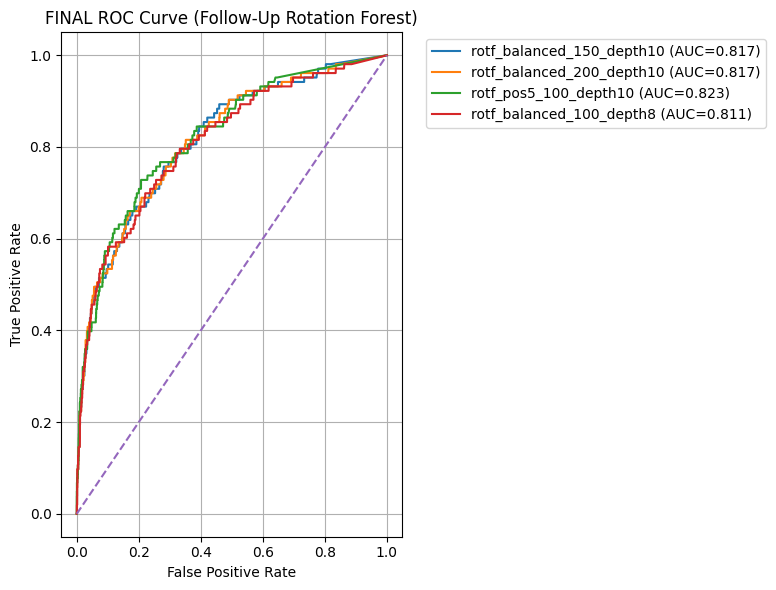

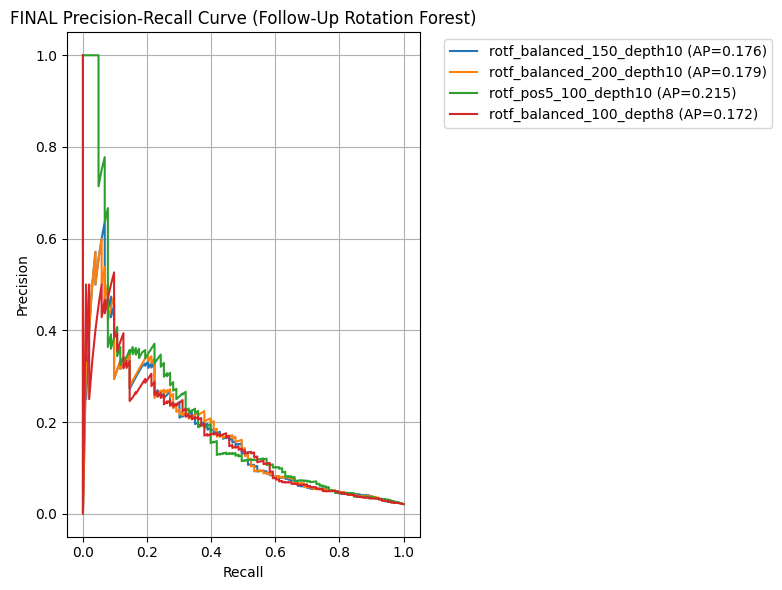

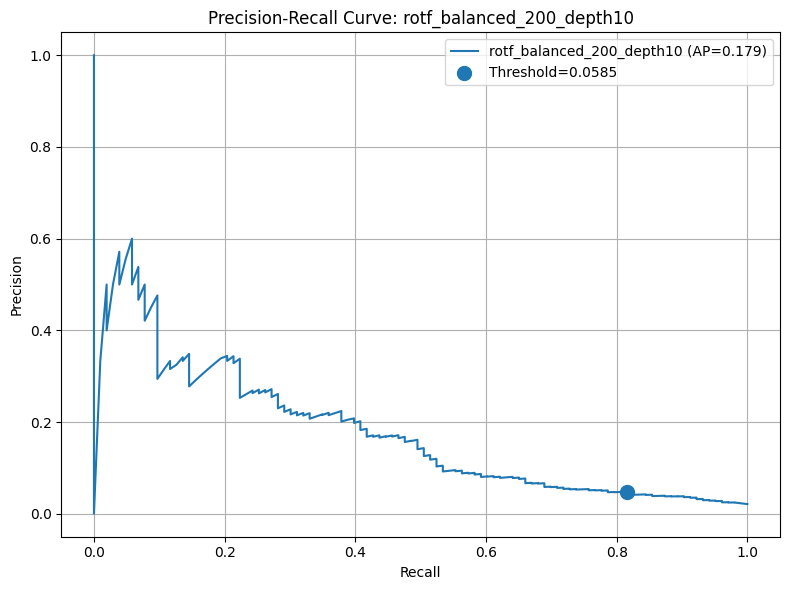

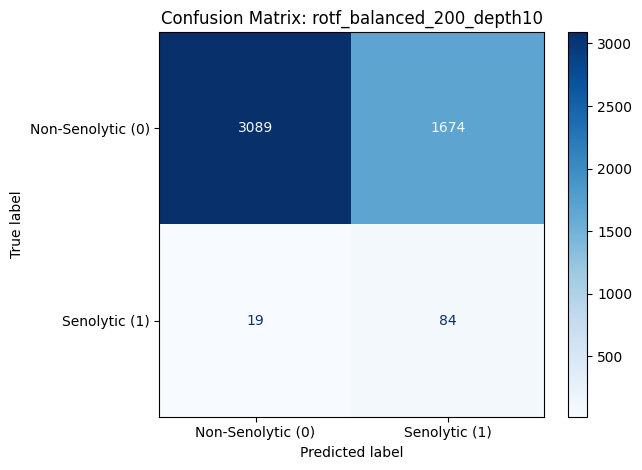

In [ ]:
# =========================================================
# FINAL ROC + PR COMPARISON (FOLLOW-UP MODELS)
# + SINGLE BEST-MODEL PR CURVE
# =========================================================

import matplotlib.pyplot as plt

# -------------------------------
# ROC CURVE: ALL FOLLOW-UP MODELS
# -------------------------------
plt.figure(figsize=(8, 6))

for r in rotation_followup_results:
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    auc = roc_auc_score(r["y_true"], r["y_prob"])
    plt.plot(fpr, tpr, label=f'{r["name"]} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("FINAL ROC Curve (Follow-Up Rotation Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------------
# PR CURVE: ALL FOLLOW-UP MODELS
# -------------------------------
plt.figure(figsize=(8, 6))

for r in rotation_followup_results:
    p, rcl, _ = precision_recall_curve(r["y_true"], r["y_prob"])
    ap = average_precision_score(r["y_true"], r["y_prob"])
    plt.plot(rcl, p, label=f'{r["name"]} (AP={ap:.3f})')

plt.title("FINAL Precision-Recall Curve (Follow-Up Rotation Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------------
# BEST MODEL OBJECT
# -------------------------------
best = [r for r in rotation_followup_results if r["name"] == best_model][0]


# -------------------------------
# SINGLE PR CURVE: BEST MODEL ONLY
# -------------------------------
best_precisions, best_recalls, best_thresholds = precision_recall_curve(
    best["y_true"], best["y_prob"]
)
best_ap = average_precision_score(best["y_true"], best["y_prob"])

plt.figure(figsize=(8, 6))
plt.plot(best_recalls, best_precisions, label=f'{best_model} (AP={best_ap:.3f})')

# mark chosen threshold if possible
if len(best_thresholds) > 0:
    idx = np.argmin(np.abs(best_thresholds - best["tuned_threshold"]))
    idx = min(idx, len(best_precisions) - 2)
    plt.scatter(
        best_recalls[idx],
        best_precisions[idx],
        s=100,
        label=f'Threshold={best["tuned_threshold"]:.4f}'
    )

plt.title(f"Precision-Recall Curve: {best_model}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------------
# CONFUSION MATRIX: BEST MODEL
# -------------------------------
disp = ConfusionMatrixDisplay(
    confusion_matrix=best["tuned_metrics"]["cm"],
    display_labels=["Non-Senolytic (0)", "Senolytic (1)"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model}")
plt.tight_layout()
plt.show()

🧾 Final Conclusion & Interpretation

This project evaluated multiple classification models to identify senolytic compounds in a highly imbalanced dataset, where only about 2% of observations belong to the positive class. Because of this imbalance, overall accuracy alone was not an appropriate metric, and the analysis instead focused on recall, precision, F1-score, ROC-AUC, and Precision-Recall (PR) curves.

🎯 Objective and Strategy

The primary goal was to develop a model that achieves high recall for the senolytic class (≥ 0.80) while maintaining as much precision as possible. This is important because missing true senolytic compounds (false negatives) is more costly than incorrectly flagging non-senolytic ones.

To achieve this, multiple model families were explored, including logistic regression and Rotation Forest, along with techniques such as:

cost-sensitive learning (class weights), parameter tuning (number of trees, depth), and threshold tuning. 🧠 Key Findings

Model Behavior Differences
The models demonstrated clear tradeoffs:

Logistic Regression achieved high recall through threshold tuning but at the cost of very low precision, resulting in many false positives. Rotation Forest (default threshold) produced more balanced predictions, with moderate precision but relatively low recall. Rotation Forest with controlled threshold tuning successfully reached the recall target (≈ 0.81) while maintaining slightly higher precision than logistic regression and producing fewer false positives.

This indicates that:

Logistic regression is effective at capturing most positives, but Rotation Forest provides a better balance between identifying positives and limiting false alarms when properly tuned.

Final Model Selection
The best-performing model was:

👉 Rotation Forest with balanced weights, 200 trees, and depth limit (depth = 10)

This model:

achieved recall ≈ 0.8155 maintained precision ≈ 0.0478 reduced false positives compared to logistic regression demonstrated stable probability estimates (no threshold collapse)

This makes it the strongest model for the stated objective.

📊 Role of Stratified Cross-Validation

The evaluation used Stratified 5-Fold Cross-Validation, which ensures that each fold maintains the same class distribution as the original dataset.

This is especially important in imbalanced datasets because:

it prevents folds from having too few or no positive samples, ensures that performance metrics (especially recall and precision) are reliable, and reduces variance in model evaluation.

Thus, stratification provided a more accurate and fair assessment of model performance across all folds.

📈 Understanding the Precision-Recall (PR) Curve

The Precision-Recall curve illustrates the tradeoff between:

Recall (how many true positives are captured) and Precision (how many predicted positives are actually correct)

Unlike the ROC curve, which can appear overly optimistic in imbalanced datasets, the PR curve focuses specifically on the minority class performance.

In this project:

The PR curve helped visualize how precision drops as recall increases. It showed that achieving very high recall inevitably leads to lower precision. It confirmed that the selected Rotation Forest model provides a better tradeoff than alternatives at high recall levels.

The Average Precision (AP) score further summarized this relationship, with higher values indicating better overall performance in identifying the positive class.

🔥 Final Takeaway

The results show that:

In highly imbalanced classification problems, model performance depends not only on the algorithm but also on how decision thresholds and class weighting are handled.

While simpler models like logistic regression can achieve high recall, ensemble methods like Rotation Forest can provide a more controlled and balanced solution, especially when paired with careful parameter tuning and threshold selection.

